In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy.ma as ma

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path='/content/drive/My Drive/Work7_MAUNet_Light_Data_Model_Result'

In [4]:
#Load Gridded Test Results

MAUNet_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_MAUNet_TRMMIMD_TestResult.npy')
SRDRN_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_SRDRN_TRMMIMD_TestResult.npy')
MAUNet_Light_KR_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_MAUNet_Light_KR_TRMMIMD_TestResult.npy')
MAUNet_Light_GT_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_MAUNet_Light_TrainWithGT_TRMMIMD_TestResult.npy')
MAUNet_Light_MP_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_MAUNet_Light_TrainWithTeacherPred_TRMMIMD_TestResult.npy')
QDM_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_QDM_TRMMIMD_TestResult.npy')
QM_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_QM_TRMMIMD_TestResult.npy')
BiasData_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_BiasData_Test_TRMMIMD.npy')
Label_Test_Grid=np.load(path+'/Result/DailyGridded/Work7_Label_Test_TRMMIMD.npy')

In [5]:
datamask=np.load(path+"/Data/Mask-TRMM128x128.npy")

In [6]:
testmask=[]
for i in range(len(Label_Test_Grid)):
  testmask.append(datamask)
testmask=np.array(testmask)

In [7]:
Masked_MAUNet_Test_Grid=ma.masked_array(MAUNet_Test_Grid, mask=testmask)
Masked_SRDRN_Test_Grid=ma.masked_array(SRDRN_Test_Grid, mask=testmask)
Masked_MAUNet_Light_GT_Test_Grid=ma.masked_array(MAUNet_Light_GT_Test_Grid, mask=testmask)
Masked_MAUNet_Light_MP_Test_Grid=ma.masked_array(MAUNet_Light_MP_Test_Grid, mask=testmask)
Masked_MAUNet_Light_KR_Test_Grid=ma.masked_array(MAUNet_Light_KR_Test_Grid, mask=testmask)
Masked_QDM_Test_Grid=ma.masked_array(QDM_Test_Grid, mask=testmask)
Masked_QM_Test_Grid=ma.masked_array(QM_Test_Grid, mask=testmask)
Masked_BiasData_Test_Grid=ma.masked_array(BiasData_Test_Grid, mask=testmask)
Masked_Label_Test_Grid=ma.masked_array(Label_Test_Grid, mask=testmask)

##RMSE Calculation

In [8]:
from sklearn.metrics import root_mean_squared_error
import math
def rmse_cal(GT,r):
  rmse=root_mean_squared_error(GT,r)
  return np.round(rmse,4)

In [9]:
def mean_cal(Data,Mask):
  sum_value=0
  count=0
  for i in range(128):
    for j in range(128):
      if Mask[i,j]==0 and np.isnan(Data[i,j])==False:
        sum_value=sum_value+Data[i,j]
        count=count+1
  mean_value=np.round((sum_value/count),4)
  return mean_value

In [10]:
def rmse_spatial(GT,res):
  rmse_grid=np.zeros((128,128))
  for i in range(128):
    for j in range(128):
      if datamask[i,j]==0:
        rmse_grid[i,j]= rmse_cal(GT[:,i,j],res[:,i,j])
  return rmse_grid

In [11]:
#Calculate RMSE at each GRID location
RMSE_MAUNet_Test_Grid=rmse_spatial(Label_Test_Grid,MAUNet_Test_Grid)
RMSE_SRDRN_Test_Grid=rmse_spatial(Label_Test_Grid,SRDRN_Test_Grid)
RMSE_MAUNet_Light_GT_Test_Grid=rmse_spatial(Label_Test_Grid,MAUNet_Light_GT_Test_Grid)
RMSE_MAUNet_Light_MP_Test_Grid=rmse_spatial(Label_Test_Grid,MAUNet_Light_MP_Test_Grid)
RMSE_MAUNet_Light_KR_Test_Grid=rmse_spatial(Label_Test_Grid,MAUNet_Light_KR_Test_Grid)
RMSE_QDM_Test_Grid=rmse_spatial(Label_Test_Grid,QDM_Test_Grid)
RMSE_QM_Test_Grid=rmse_spatial(Label_Test_Grid,QM_Test_Grid)
RMSE_BiasData_Test_Grid=rmse_spatial(Label_Test_Grid,BiasData_Test_Grid)

In [12]:
#Mask Gridded RMSE
import numpy.ma as ma
MRMSE_MAUNet_Test_Grid=ma.masked_array(RMSE_MAUNet_Test_Grid, mask=datamask)
MRMSE_SRDRN_Test_Grid=ma.masked_array(RMSE_SRDRN_Test_Grid, mask=datamask)
MRMSE_MAUNet_Light_GT_Test_Grid=ma.masked_array(RMSE_MAUNet_Light_GT_Test_Grid, mask=datamask)
MRMSE_MAUNet_Light_MP_Test_Grid=ma.masked_array(RMSE_MAUNet_Light_MP_Test_Grid, mask=datamask)
MRMSE_MAUNet_Light_KR_Test_Grid=ma.masked_array(RMSE_MAUNet_Light_KR_Test_Grid, mask=datamask)
MRMSE_QDM_Test_Grid=ma.masked_array(RMSE_QDM_Test_Grid, mask=datamask)
MRMSE_QM_Test_Grid=ma.masked_array(RMSE_QM_Test_Grid, mask=datamask)
MRMSE_BiasData_Test_Grid=ma.masked_array(RMSE_BiasData_Test_Grid, mask=datamask)

In [13]:
#Calculate Mean of Gridded RMSE
Grid_RMSE_S_Mean_MAUNet_Ts=mean_cal(MRMSE_MAUNet_Test_Grid,datamask)
Grid_RMSE_S_Mean_SRDRN_Ts=mean_cal(MRMSE_SRDRN_Test_Grid,datamask)
Grid_RMSE_S_Mean_MAUNet_Light_GT_Ts=mean_cal(MRMSE_MAUNet_Light_GT_Test_Grid,datamask)
Grid_RMSE_S_Mean_MAUNet_Light_MP_Ts=mean_cal(MRMSE_MAUNet_Light_MP_Test_Grid,datamask)
Grid_RMSE_S_Mean_MAUNet_Light_KR_Ts=mean_cal(MRMSE_MAUNet_Light_KR_Test_Grid,datamask)
Grid_RMSE_S_Mean_QDM_Ts=mean_cal(MRMSE_QDM_Test_Grid,datamask)
Grid_RMSE_S_Mean_QM_Ts=mean_cal(MRMSE_QM_Test_Grid,datamask)
Grid_RMSE_S_Mean_BiasData_Ts=mean_cal(MRMSE_BiasData_Test_Grid,datamask)

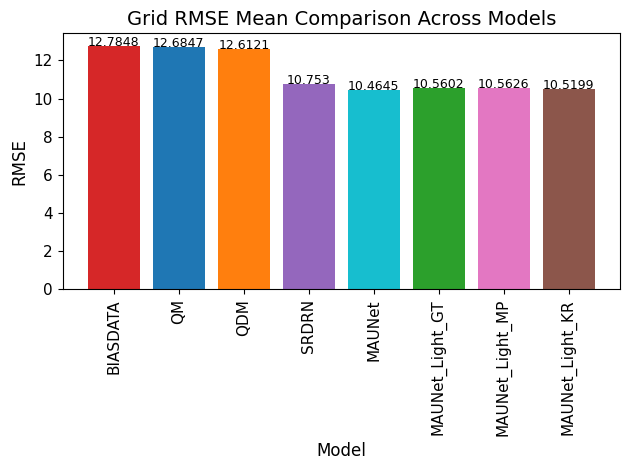

In [14]:
import matplotlib.pyplot as plt

# Function to add labels to bars
def addlabels(x, y):
    for i in range(len(x)):
        plt.text(i, y[i], round(y[i], 4), ha='center', fontsize=9)

# Data
METHOD = ['BIASDATA', 'QM', 'QDM', 'SRDRN', 'MAUNet', 'MAUNet_Light_GT', 'MAUNet_Light_MP', 'MAUNet_Light_KR']
RMSE_GRID_MEAN_TS = [
    Grid_RMSE_S_Mean_BiasData_Ts, Grid_RMSE_S_Mean_QM_Ts, Grid_RMSE_S_Mean_QDM_Ts, Grid_RMSE_S_Mean_SRDRN_Ts,
    Grid_RMSE_S_Mean_MAUNet_Ts, Grid_RMSE_S_Mean_MAUNet_Light_GT_Ts, Grid_RMSE_S_Mean_MAUNet_Light_MP_Ts,
    Grid_RMSE_S_Mean_MAUNet_Light_KR_Ts]

# Distinct colors for each bar
bar_colors = ['tab:red', 'tab:blue', 'tab:orange', 'tab:purple', 'tab:cyan', 'tab:green', 'tab:pink', 'tab:brown']

# Create the bar chart
fig, ax = plt.subplots()
ax.bar(METHOD, RMSE_GRID_MEAN_TS, color=bar_colors)

# Add value labels on each bar
addlabels(METHOD, RMSE_GRID_MEAN_TS)

# Set x and y labels
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)

# Customize the x-ticks to be vertical
plt.xticks(rotation=90, fontsize=11)
plt.yticks(fontsize=11)

# Title for the plot
plt.title('Grid RMSE Mean Comparison Across Models', fontsize=14)

# Add legend with a title
#ax.legend(METHOD, title='Models', loc="lower right")

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()


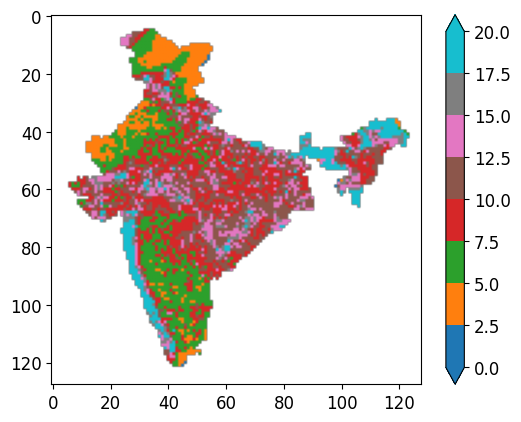

In [28]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab10"]
bounds = [0, 2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow( MRMSE_MAUNet_Test_Grid, cmap=cmap, norm=norm)

# Adjust x and y tick fonts
ax.tick_params(axis='both', labelsize=12)

# Colorbar
cbar = fig.colorbar( im, ax=ax, orientation="vertical", ticks=bounds, extend="both")
cbar.ax.tick_params(labelsize=12)
plt.show()

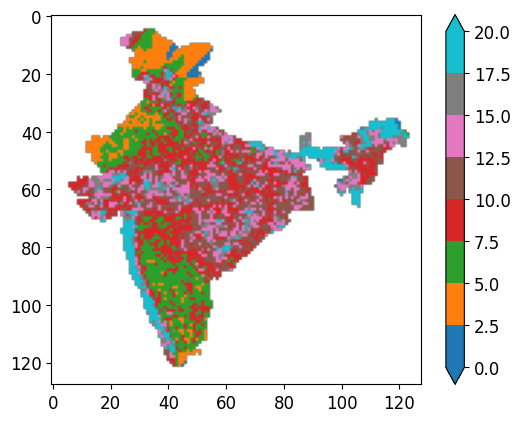

In [32]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab10"]
bounds = [0, 2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow( MRMSE_SRDRN_Test_Grid, cmap=cmap, norm=norm)

# Adjust x and y tick fonts
ax.tick_params(axis='both', labelsize=12)

# Colorbar
cbar = fig.colorbar( im, ax=ax, orientation="vertical", ticks=bounds, extend="both")
cbar.ax.tick_params(labelsize=12)
plt.show()

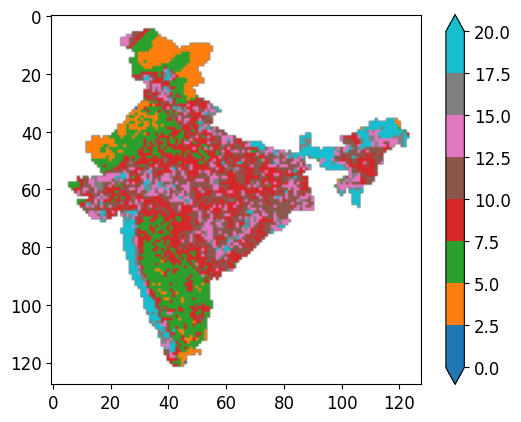

In [36]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab10"]
bounds = [0, 2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow( MRMSE_MAUNet_Light_GT_Test_Grid, cmap=cmap, norm=norm)

# Adjust x and y tick fonts
ax.tick_params(axis='both', labelsize=12)

# Colorbar
cbar = fig.colorbar( im, ax=ax, orientation="vertical", ticks=bounds, extend="both")
cbar.ax.tick_params(labelsize=12)
plt.show()

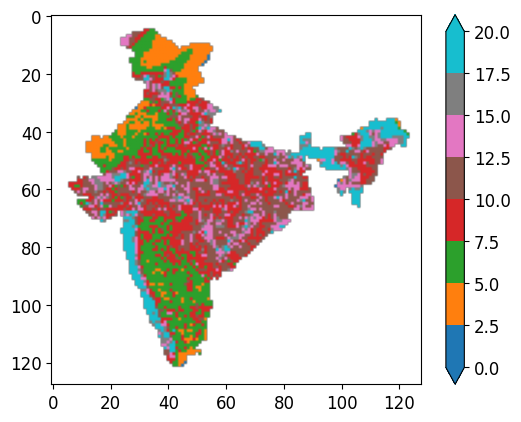

In [38]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab10"]
bounds = [0, 2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow( MRMSE_MAUNet_Light_MP_Test_Grid, cmap=cmap, norm=norm)

# Adjust x and y tick fonts
ax.tick_params(axis='both', labelsize=12)

# Colorbar
cbar = fig.colorbar( im, ax=ax, orientation="vertical", ticks=bounds, extend="both")
cbar.ax.tick_params(labelsize=12)
plt.show()

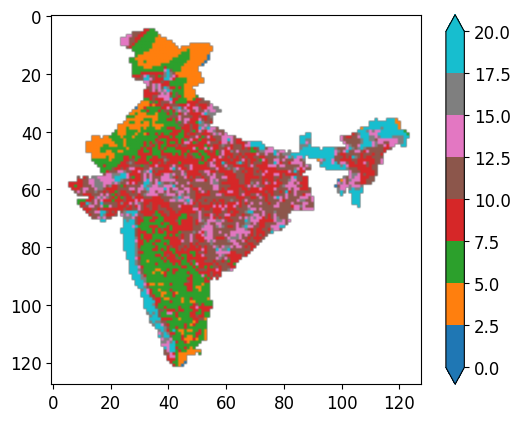

In [40]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab10"]
bounds = [0, 2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow( MRMSE_MAUNet_Light_KR_Test_Grid, cmap=cmap, norm=norm)

# Adjust x and y tick fonts
ax.tick_params(axis='both', labelsize=12)

# Colorbar
cbar = fig.colorbar( im, ax=ax, orientation="vertical", ticks=bounds, extend="both")
cbar.ax.tick_params(labelsize=12)
plt.show()

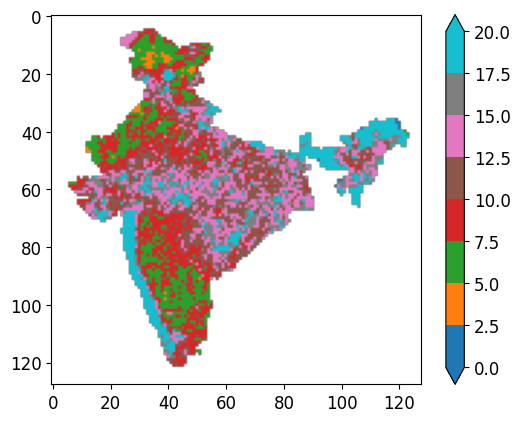

In [44]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab10"]
bounds = [0, 2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow( MRMSE_QDM_Test_Grid, cmap=cmap, norm=norm)

# Adjust x and y tick fonts
ax.tick_params(axis='both', labelsize=12)

# Colorbar
cbar = fig.colorbar( im, ax=ax, orientation="vertical", ticks=bounds, extend="both")
cbar.ax.tick_params(labelsize=12)
plt.show()

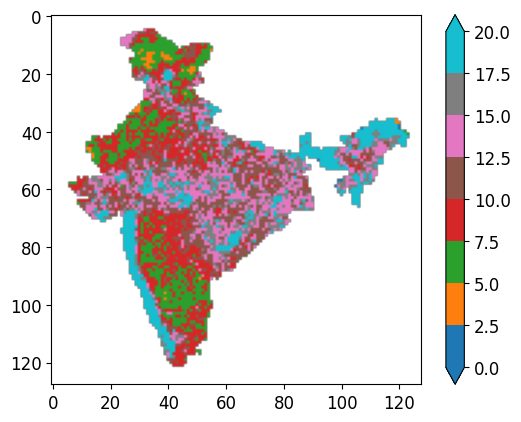

In [47]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab10"]
bounds = [0, 2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow( MRMSE_QM_Test_Grid, cmap=cmap, norm=norm)

# Adjust x and y tick fonts
ax.tick_params(axis='both', labelsize=12)

# Colorbar
cbar = fig.colorbar( im, ax=ax, orientation="vertical", ticks=bounds, extend="both")
cbar.ax.tick_params(labelsize=12)
plt.show()

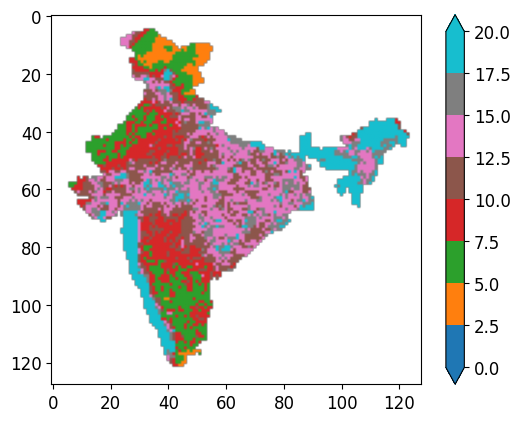

In [50]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab10"]
bounds = [0, 2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow( MRMSE_BiasData_Test_Grid, cmap=cmap, norm=norm)

# Adjust x and y tick fonts
ax.tick_params(axis='both', labelsize=12)

# Colorbar
cbar = fig.colorbar( im, ax=ax, orientation="vertical", ticks=bounds, extend="both")
cbar.ax.tick_params(labelsize=12)
plt.show()

##Correlation

In [54]:
testmask=[]
for i in range(len(Label_Test_Grid)):
  testmask.append(datamask)

In [55]:
import numpy.ma as ma
import scipy.stats.mstats as cm
GTtest_mask=ma.masked_array(Label_Test_Grid, mask=testmask)
BiasData_mask=ma.masked_array(BiasData_Test_Grid, mask=testmask)
MAUNet_mask=ma.masked_array(MAUNet_Test_Grid, mask=testmask)
SRDRN_mask=ma.masked_array(SRDRN_Test_Grid, mask=testmask)
MAUNet_Light_GT_mask=ma.masked_array(MAUNet_Light_GT_Test_Grid, mask=testmask)
MAUNet_Light_MP_mask=ma.masked_array(MAUNet_Light_MP_Test_Grid, mask=testmask)
MAUNet_Light_KR_mask=ma.masked_array(MAUNet_Light_KR_Test_Grid, mask=testmask)
QDM_mask=ma.masked_array(QDM_Test_Grid, mask=testmask)
QM_mask=ma.masked_array(QM_Test_Grid, mask=testmask)

In [56]:
#Spatial correlation gridwise training set
def grid_corr(r,l):
  corr_test_r_l=np.full((128, 128), np.nan)
  for i in range(128):
   for j in range(128):
    if datamask[i,j]==0:
     corr_test_r_l[i,j]=cm.pearsonr(r[:,i,j],l[:,i,j])[0]
  return corr_test_r_l

In [ ]:
BIASDATA_Corr_Grid= grid_corr(BiasData_mask,GTtest_mask)
MAUNet_Corr_Grid=grid_corr(MAUNet_mask,GTtest_mask)
SRDRN_Corr_Grid=grid_corr(SRDRN_mask,GTtest_mask)
MAUNet_Light_GT_Corr_Grid=grid_corr(MAUNet_Light_GT_mask,GTtest_mask)
MAUNet_Light_MP_Corr_Grid=grid_corr(MAUNet_Light_MP_mask,GTtest_mask)
MAUNet_Light_KR_Corr_Grid=grid_corr(MAUNet_Light_KR_mask,GTtest_mask)
QDM_Corr_Grid=grid_corr(QDM_mask,GTtest_mask)
QM_Corr_Grid=grid_corr(QM_mask,GTtest_mask)

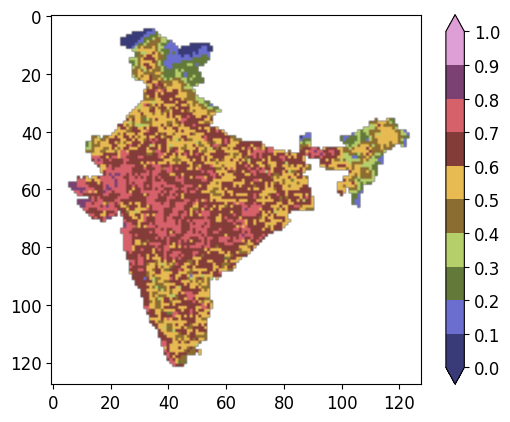

In [68]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab20b"]
bounds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow(BIASDATA_Corr_Grid, cmap=cmap, norm=norm)
ax.tick_params(axis="both", labelsize=12)
cbar = fig.colorbar(im, ax=ax, orientation="vertical", ticks=bounds, extend="both")
cbar.ax.tick_params(labelsize=12)
plt.show()

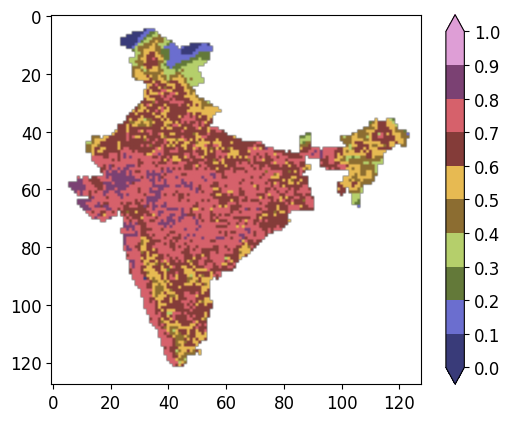

In [69]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab20b"]
bounds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow(MAUNet_Corr_Grid, cmap=cmap, norm=norm)
ax.tick_params(axis="both", labelsize=12)
cbar = fig.colorbar(im, ax=ax, orientation="vertical", ticks=bounds, extend="both")
cbar.ax.tick_params(labelsize=12)
plt.show()

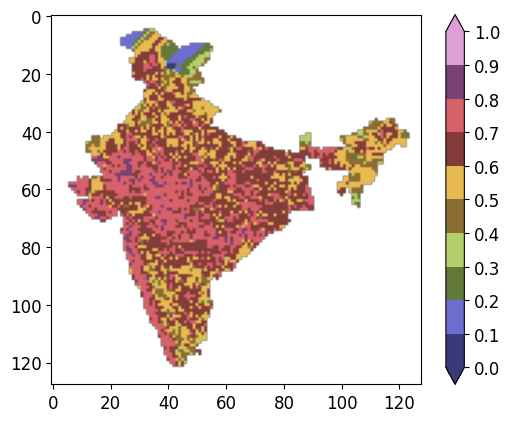

In [70]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab20b"]
bounds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow(SRDRN_Corr_Grid, cmap=cmap, norm=norm)
ax.tick_params(axis="both", labelsize=12)
cbar = fig.colorbar(im, ax=ax, orientation="vertical", ticks=bounds, extend="both")
cbar.ax.tick_params(labelsize=12)
plt.show()

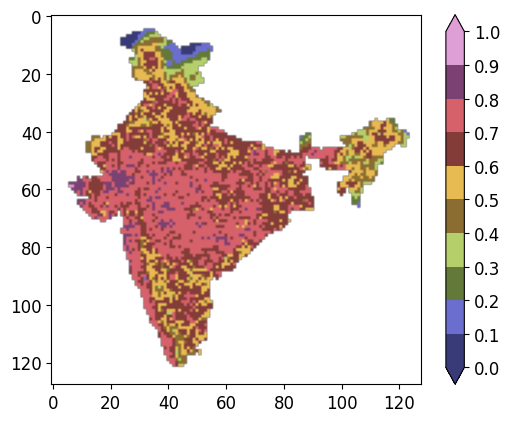

In [71]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab20b"]
bounds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow(MAUNet_Light_GT_Corr_Grid, cmap=cmap, norm=norm)
ax.tick_params(axis="both", labelsize=12)
cbar = fig.colorbar(im, ax=ax, orientation="vertical", ticks=bounds, extend="both")
cbar.ax.tick_params(labelsize=12)
plt.show()


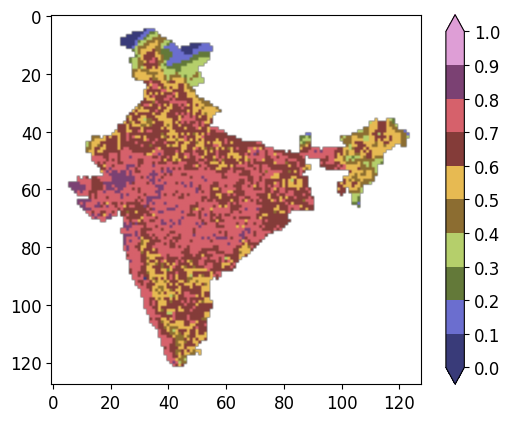

In [72]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab20b"]
bounds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow(MAUNet_Light_MP_Corr_Grid, cmap=cmap, norm=norm)
ax.tick_params(axis="both", labelsize=12)
cbar = fig.colorbar(im, ax=ax, orientation="vertical", ticks=bounds, extend="both")
cbar.ax.tick_params(labelsize=12)
plt.show()

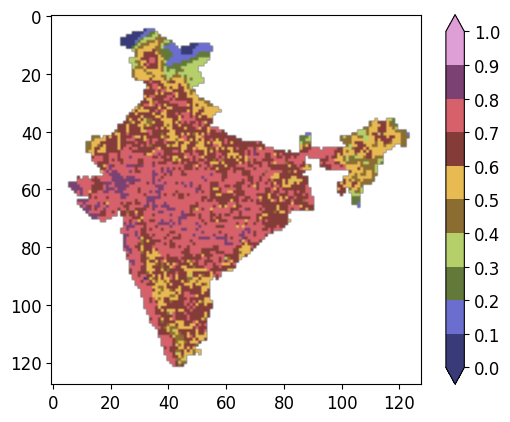

In [73]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab20b"]
bounds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow(MAUNet_Light_KR_Corr_Grid, cmap=cmap, norm=norm)
ax.tick_params(axis="both", labelsize=12)
cbar = fig.colorbar(im, ax=ax, orientation="vertical", ticks=bounds, extend="both")
cbar.ax.tick_params(labelsize=12)
plt.show()

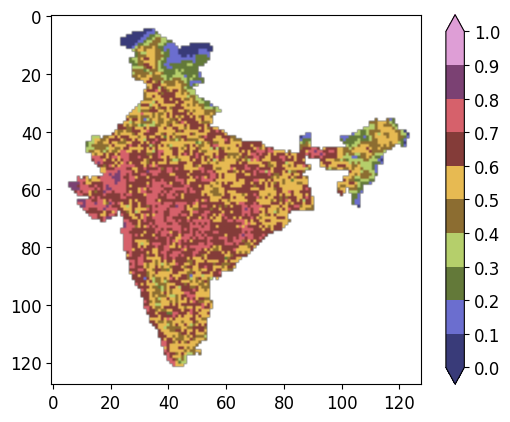

In [74]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab20b"]
bounds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow(QDM_Corr_Grid, cmap=cmap, norm=norm)
ax.tick_params(axis="both", labelsize=12)
cbar = fig.colorbar(im, ax=ax, orientation="vertical", ticks=bounds, extend="both")
cbar.ax.tick_params(labelsize=12)
plt.show()

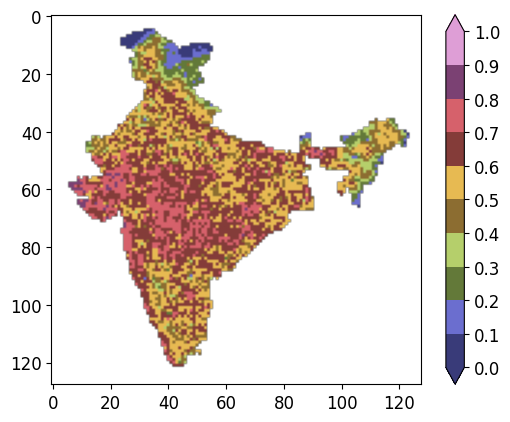

In [75]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.colormaps["tab20b"]
bounds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
fig, ax = plt.subplots()
im = ax.imshow(QM_Corr_Grid, cmap=cmap, norm=norm)
ax.tick_params(axis="both", labelsize=12)
cbar = fig.colorbar(im, ax=ax, orientation="vertical", ticks=bounds, extend="both")
cbar.ax.tick_params(labelsize=12)
plt.show()

In [76]:
Grid_Corr_S_Mean_MAUNet_Ts=mean_cal(MAUNet_Corr_Grid,datamask)
Grid_Corr_S_Mean_SRDRN_Ts=mean_cal(SRDRN_Corr_Grid,datamask)
Grid_Corr_S_Mean_MAUNet_Light_GT_Ts=mean_cal(MAUNet_Light_GT_Corr_Grid,datamask)
Grid_Corr_S_Mean_MAUNet_Light_MP_Ts=mean_cal(MAUNet_Light_MP_Corr_Grid,datamask)
Grid_Corr_S_Mean_MAUNet_Light_KR_Ts=mean_cal(MAUNet_Light_KR_Corr_Grid,datamask)
Grid_Corr_S_Mean_QDM_Ts=mean_cal(QDM_Corr_Grid,datamask)
Grid_Corr_S_Mean_QM_Ts=mean_cal(QM_Corr_Grid,datamask)
Grid_Corr_S_Mean_BiasData_Ts=mean_cal(BIASDATA_Corr_Grid,datamask)

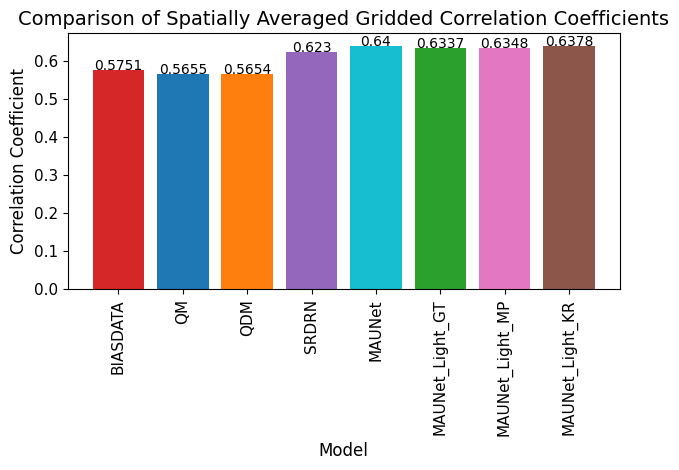

In [80]:
import matplotlib.pyplot as plt

# Function to add labels to bars
def addlabels(x, y):
    for i in range(len(x)):
        plt.text(i, y[i], round(y[i], 4), ha='center', fontsize=10)

# Data for models and correlation coefficients (now including SRDRN)
METHOD = ['BIASDATA', 'QM', 'QDM', 'SRDRN', 'MAUNet', 'MAUNet_Light_GT', 'MAUNet_Light_MP', 'MAUNet_Light_KR']
Corr_GRID_MEAN_TS = [
    Grid_Corr_S_Mean_BiasData_Ts, Grid_Corr_S_Mean_QM_Ts, Grid_Corr_S_Mean_QDM_Ts, Grid_Corr_S_Mean_SRDRN_Ts,
    Grid_Corr_S_Mean_MAUNet_Ts, Grid_Corr_S_Mean_MAUNet_Light_GT_Ts, Grid_Corr_S_Mean_MAUNet_Light_MP_Ts,
    Grid_Corr_S_Mean_MAUNet_Light_KR_Ts ]

# Colors for each bar
bar_colors = ['tab:red', 'tab:blue', 'tab:orange', 'tab:purple', 'tab:cyan', 'tab:green', 'tab:pink', 'tab:brown', 'tab:gray']

# Create the bar chart
fig, ax = plt.subplots()
ax.bar(METHOD, Corr_GRID_MEAN_TS, color=bar_colors)

# Add labels on each bar
addlabels(METHOD, Corr_GRID_MEAN_TS)

# Set x and y labels
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Correlation Coefficient', fontsize=12)

# Customize x-ticks and y-ticks
plt.xticks(rotation=90, fontsize=11)  # Rotate x-ticks for better readability
plt.yticks(fontsize=11)

# Title (optional, uncomment if needed)
plt.title('Comparison of Spatially Averaged Gridded Correlation Coefficients', fontsize=14)

# Add a legend
#ax.legend(METHOD, title='Models', loc="lower right")

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()
